#  Human Activity Recognition using Hidden Markov Models
**Group Members:** Fidele Ndihokubwayo | Jean de Dieu Muhirwa Harerimana

**Date:** March 03 2026

---

## Project Overview
This notebook implements Hidden Markov Models (HMM) to classify four human activities
— **Standing, Walking, Jumping, Still** — from accelerometer and gyroscope signals
collected using the Sensor Logger app and preprocessed into merged CSV files.

### Dataset Structure
```
dataset/
├── train/
│   ├── jumping/   → jumping_001.csv ... jumping_010.csv
│   ├── walking/   → walking_001.csv  ... walking_010.csv
│   ├── standing/  → standing_001.csv ... standing_010.csv
│   └── still/     → still_001.csv    ... still_010.csv
└── test/
    ├── jumping/   → jumping_011.csv ... jumping_013.csv
    ├── walking/   → walking_011.csv  ... walking_013.csv
    ├── standing/  → standing_011.csv ... standing_013.csv
    └── still/     → still_011.csv    ... still_013.csv
```

### Notebook Steps
1. Setup & Imports  
2. Configuration & Constants  
3. Data Loading & Preprocessing  
4. Raw Signal Visualisation  
5. Feature Extraction (Time + Frequency Domain)  
6. Sliding Window & Feature Matrix  
7. Z-score Normalization  
8. Feature Distribution Visualisation  
9. HMM Training — Baum-Welch Algorithm  
10. Transition & Emission Probability Visualisation  
11. Viterbi Decoding & Classification  
12. Evaluation on Unseen Test Data  
13. Confusion Matrix & Per-class Metrics  
14. Decoded Activity Sequence Plots  
15. Baum-Welch Convergence Plots  
16. Final Summary

In [2]:
# ── Environment Setup ──────────────────────────────────────
!pip install hmmlearn -q

# Clone YOUR fork of the repo (has all the data)
!git clone https://github.com/Fidele012/Formative-2---Hidden-Markov-Models.git

import os
os.chdir('Formative-2---Hidden-Markov-Models')

# Verify everything is there
print("✅ Repo cloned successfully\n")
print("📁 Dataset structure:")
for activity in ['standing', 'still', 'walking', 'jumping']:
    train_files = !find dataset/train/{activity} -name "*.csv" 2>/dev/null
    test_files  = !find dataset/test/{activity}  -name "*.csv" 2>/dev/null
    print(f"   {activity:<12}: {len(train_files):>2} train | {len(test_files):>2} test")

Cloning into 'Formative-2---Hidden-Markov-Models'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (226/226), done.
remote: Total 240 (delta 20), reused 225 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (240/240), 15.17 MiB | 13.39 MiB/s, done.
Resolving deltas: 100% (20/20), done.
✅ Repo cloned successfully

📁 Dataset structure:
   standing    : 14 train |  3 test
   still       : 14 train |  3 test
   walking     : 14 train |  3 test
   jumping     : 15 train |  4 test


---
## Step 1: Setup & Imports

Install all required packages before running:
```bash
pip install hmmlearn scikit-learn matplotlib seaborn scipy numpy pandas
```

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn import hmm
from collections import Counter
import os, glob, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
os.makedirs('figures', exist_ok=True)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


---
## Step 2: Configuration & Constants

### Sampling Rate Harmonization
consistent time grid
across all recordings from both partners.

### Window Size Justification
At **100 Hz**, a window of **100 samples = 1 second**. This is chosen because:
- One full walking stride cycle ≈ 0.8–1.2 seconds → captured completely in 1s
- FFT frequency resolution = fs/N = 100/100 = **1 Hz** — fine enough to
  distinguish walking (~1–2 Hz) from jumping (~2–4 Hz) and still (~0 Hz)
- **50% overlap** (step = 50 samples) doubles our training windows and
  prevents missing activity transitions at window boundaries

In [4]:
# ── Global Configuration ──────────────────────────────────────────────────────

SAMPLING_RATE = 100          # Hz  (recorded at 99.4 Hz → harmonized to 100 Hz)
WINDOW_SIZE   = 100          # samples = 1.0 second per window at 100 Hz
STEP_SIZE     = 50           # 50% overlap between consecutive windows

ACTIVITIES   = ['standing', 'walking', 'jumping', 'still']
ACTIVITY_MAP = {a: i for i, a in enumerate(ACTIVITIES)}
IDX_MAP      = {i: a for a, i in ACTIVITY_MAP.items()}

# ── Dataset paths — matches your GitHub repo structure ─────────────────────────
TRAIN_DIR = 'dataset/train'
TEST_DIR  = 'dataset/test'

# ── HMM Hyperparameters ────────────────────────────────────────────────────────
N_COMPONENTS    = 4       # hidden states per activity HMM
COVARIANCE_TYPE = 'diag'  # diagonal covariance — efficient for high-dim features
N_ITER          = 200     # maximum Baum-Welch iterations
CONVERGENCE_TOL = 1e-4    # stop when Δ log-likelihood < this (proper convergence)

print("✅ Configuration set")
print(f"   Sampling rate : {SAMPLING_RATE} Hz")
print(f"   Window size   : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f}s")
print(f"   Step size     : {STEP_SIZE} samples = {STEP_SIZE/SAMPLING_RATE:.1f}s (50% overlap)")
print(f"   Activities    : {ACTIVITIES}")
print(f"   Train dir     : {TRAIN_DIR}")
print(f"   Test dir      : {TEST_DIR}")

✅ Configuration set
   Sampling rate : 100 Hz
   Window size   : 100 samples = 1.0s
   Step size     : 50 samples = 0.5s (50% overlap)
   Activities    : ['standing', 'walking', 'jumping', 'still']
   Train dir     : dataset/train
   Test dir      : dataset/test


In [5]:
def load_csv(filepath: str, target_rate: int = SAMPLING_RATE) -> pd.DataFrame:
    """
    Load one merged CSV file produced by the partner's preprocessing script.

    Handles columns: time, seconds_elapsed, accel_x, accel_y, accel_z,
                                            gyro_x,  gyro_y,  gyro_z

    Steps:
      1. Read CSV and rename accel_* -> acc_* for internal consistency
      2. Sort by seconds_elapsed to ensure chronological order
      3. Resample to target_rate Hz to harmonize sampling rates between phones
      4. Return clean DataFrame with 7 columns (time + 6 sensor axes)
    """
    df = pd.read_csv(filepath)

    # Rename columns to internal standard
    df = df.rename(columns={
        'accel_x': 'acc_x',
        'accel_y': 'acc_y',
        'accel_z': 'acc_z'
        # gyro_x/y/z already match our standard
    })

    # Keep only needed columns, sort by time
    sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
    df = df[['seconds_elapsed'] + sensor_cols].dropna()
    df = df.sort_values('seconds_elapsed').reset_index(drop=True)

    # Resample to exactly target_rate Hz
    # This harmonizes recordings from phones with different sampling rates
    duration_sec   = df['seconds_elapsed'].max() - df['seconds_elapsed'].min()
    target_samples = int(duration_sec * target_rate)

    if target_samples > 1 and abs(len(df) - target_samples) > 2:
        resampled = resample(df[sensor_cols].values, target_samples)
        new_time  = np.linspace(df['seconds_elapsed'].min(),
                                df['seconds_elapsed'].max(), target_samples)
        df = pd.DataFrame(resampled, columns=sensor_cols)
        df.insert(0, 'seconds_elapsed', new_time)

    return df.reset_index(drop=True)


def load_dataset(data_dir: str) -> tuple:
    """
    Load all CSV files from dataset/train/ or dataset/test/.

    Expected structure:
        data_dir/
            standing/ → standing_001.csv, standing_002.csv ...
            walking/  → walking_001.csv  ...
            jumping/  → jumping_001.csv  ...
            still/    → still_001.csv    ...

    Returns:
        data_list : list of (DataFrame, int_label) tuples
        summary   : dict with file counts and durations per activity
    """
    data_list = []
    summary   = {}

    for activity in ACTIVITIES:
        label    = ACTIVITY_MAP[activity]
        act_dir  = os.path.join(data_dir, activity)
        files    = sorted(glob.glob(os.path.join(act_dir, '*.csv')))

        summary[activity] = {'files': 0, 'total_seconds': 0.0, 'file_list': []}

        for fpath in files:
            try:
                df = load_csv(fpath)
                if len(df) >= WINDOW_SIZE:   # skip files too short for 1 window
                    data_list.append((df, label))
                    dur = df['seconds_elapsed'].max() - df['seconds_elapsed'].min()
                    summary[activity]['files']         += 1
                    summary[activity]['total_seconds'] += dur
                    summary[activity]['file_list'].append(os.path.basename(fpath))
            except Exception as e:
                print(f"  ⚠ Skipping {os.path.basename(fpath)}: {e}")

    return data_list, summary


# ── Load Training Data ─────────────────────────────────────────────────────────
print("📂 Loading training data...")
print("="*60)
train_data, train_summary = load_dataset(TRAIN_DIR)

print(f"{'Activity':<12} {'Files':>6} {'Total Duration':>16} {'Status':>10}")
print("-"*48)
total_files = 0
for act, info in train_summary.items():
    dur    = info['total_seconds']
    status = '✅' if dur >= 90 else '⚠  <90s'
    print(f"{act:<12} {info['files']:>6}    {dur:>10.1f}s    {status}")
    total_files += info['files']
print("-"*48)
print(f"{'TOTAL':<12} {total_files:>6}")
print(f"\n✅ {len(train_data)} training recordings loaded successfully")

📂 Loading training data...
Activity      Files   Total Duration     Status
------------------------------------------------
standing         14         140.0s    ✅
walking          14         152.5s    ✅
jumping          15         169.1s    ✅
still            14         144.9s    ✅
------------------------------------------------
TOTAL            57

✅ 57 training recordings loaded successfully


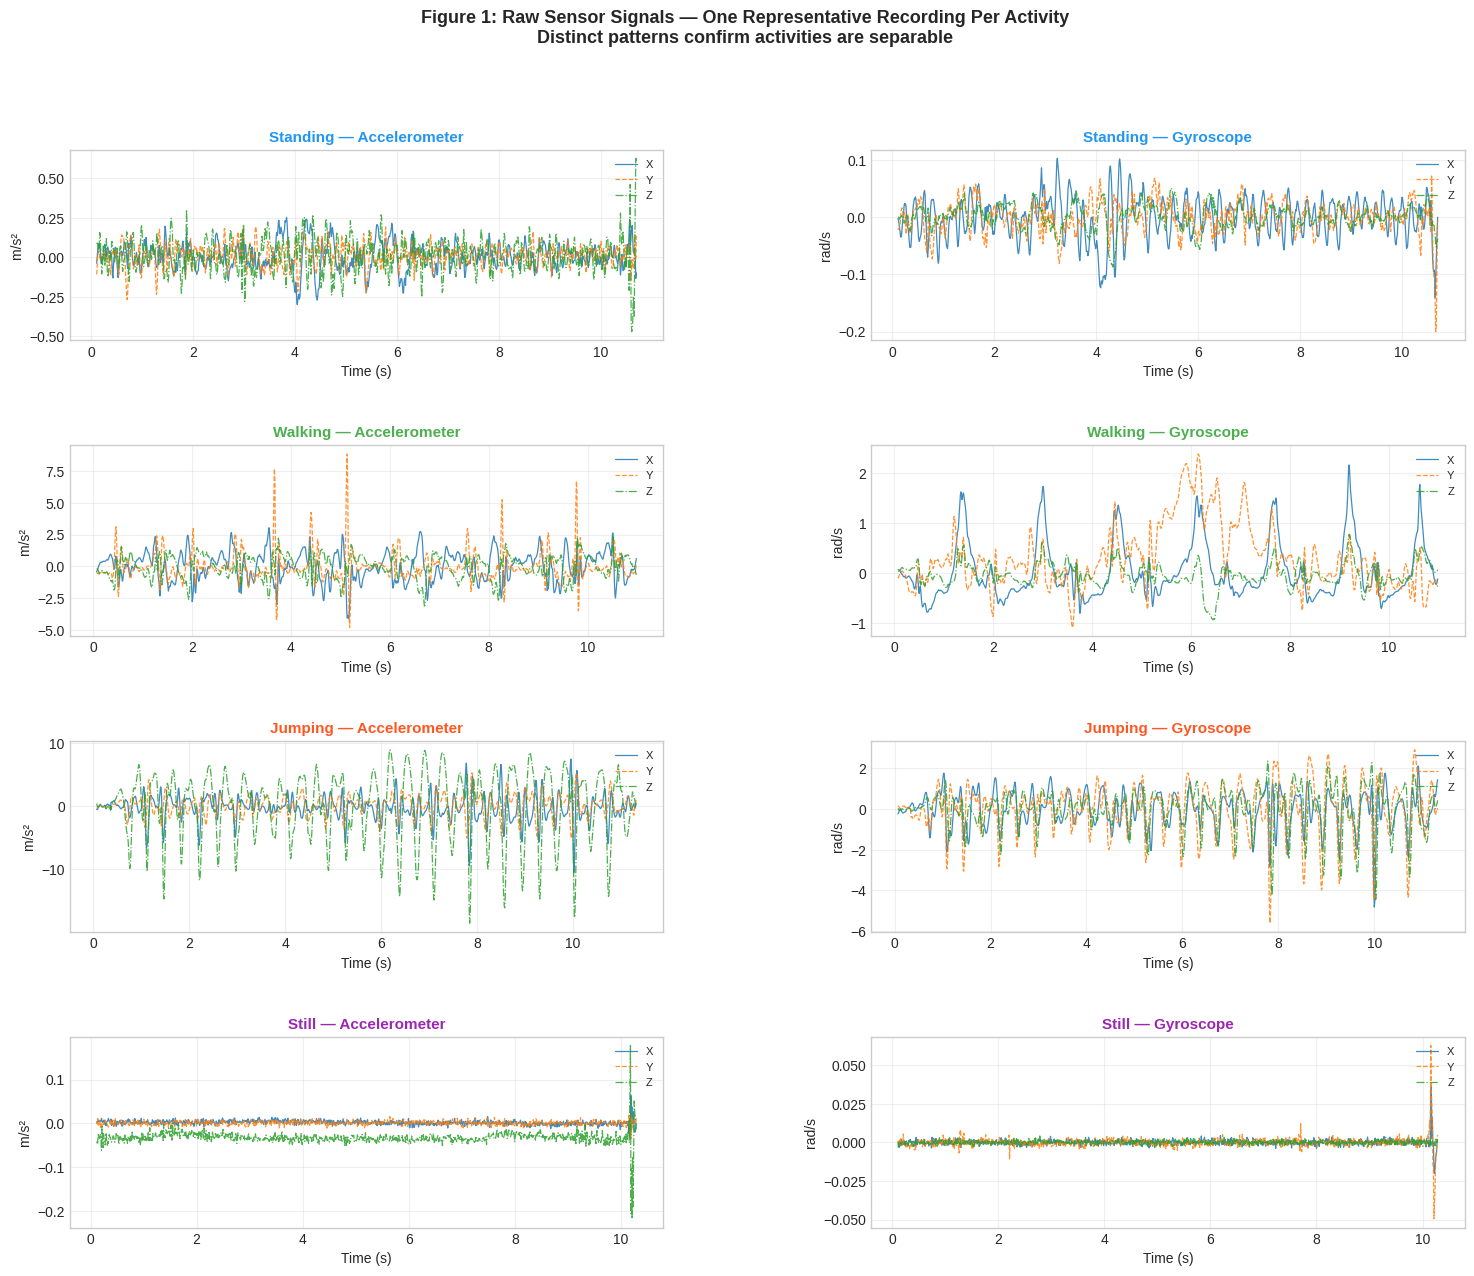

✅ Figure 1 saved → figures/fig1_raw_signals.png


In [6]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for idx, (activity, color) in enumerate(zip(ACTIVITIES, colors)):
    label     = ACTIVITY_MAP[activity]
    sample_df = next((df for df, lbl in train_data if lbl == label), None)
    if sample_df is None:
        print(f"⚠ No training data found for {activity}")
        continue

    t = sample_df['seconds_elapsed']

    # Accelerometer subplot
    ax1 = fig.add_subplot(gs[idx, 0])
    for col, ls in zip(['acc_x','acc_y','acc_z'], ['-','--','-.']):
        ax1.plot(t, sample_df[col], linestyle=ls, linewidth=0.9, alpha=0.85,
                 label=col.split('_')[1].upper())
    ax1.set_title(f'{activity.capitalize()} — Accelerometer',
                  fontsize=11, fontweight='bold', color=color)
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('m/s²')
    ax1.legend(fontsize=8, loc='upper right'); ax1.grid(True, alpha=0.3)

    # Gyroscope subplot
    ax2 = fig.add_subplot(gs[idx, 1])
    for col, ls in zip(['gyro_x','gyro_y','gyro_z'], ['-','--','-.']):
        ax2.plot(t, sample_df[col], linestyle=ls, linewidth=0.9, alpha=0.85,
                 label=col.split('_')[1].upper())
    ax2.set_title(f'{activity.capitalize()} — Gyroscope',
                  fontsize=11, fontweight='bold', color=color)
    ax2.set_xlabel('Time (s)'); ax2.set_ylabel('rad/s')
    ax2.legend(fontsize=8, loc='upper right'); ax2.grid(True, alpha=0.3)

fig.suptitle('Figure 1: Raw Sensor Signals — One Representative Recording Per Activity\n'
             'Distinct patterns confirm activities are separable',
             fontsize=13, fontweight='bold')
plt.savefig('figures/fig1_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved → figures/fig1_raw_signals.png")

In [7]:
def extract_features(window: np.ndarray, fs: int = SAMPLING_RATE) -> np.ndarray:
    """
    Extract a 30-element feature vector from one sensor window.

    Parameters
    ----------
    window : np.ndarray, shape (WINDOW_SIZE, 6)
             Columns: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
    fs     : int — sampling frequency in Hz

    Returns
    -------
    features : np.ndarray, shape (30,)
    """
    acc  = window[:, :3]   # accelerometer — first 3 columns
    gyro = window[:, 3:]   # gyroscope     — last  3 columns
    feat = []

    # ── TIME DOMAIN ─────────────────────────────────────────────────────────

    # 1. Mean per axis — captures gravity component & orientation (6 values)
    feat.extend(np.mean(acc,  axis=0))
    feat.extend(np.mean(gyro, axis=0))

    # 2. Standard Deviation — signal variability & movement intensity (6 values)
    feat.extend(np.std(acc,  axis=0))
    feat.extend(np.std(gyro, axis=0))

    # 3. RMS (Root Mean Square) — signal energy content (6 values)
    feat.extend(np.sqrt(np.mean(acc  ** 2, axis=0)))
    feat.extend(np.sqrt(np.mean(gyro ** 2, axis=0)))

    # 4. Signal Magnitude Area — scalar total motion intensity (2 values)
    feat.append(np.sum(np.abs(acc))  / len(acc))
    feat.append(np.sum(np.abs(gyro)) / len(gyro))

    # 5. Inter-axis correlations — coordinated limb motion during walking (2 values)
    feat.append(np.corrcoef(acc[:, 0], acc[:, 1])[0, 1])  # acc X-Y
    feat.append(np.corrcoef(acc[:, 1], acc[:, 2])[0, 1])  # acc Y-Z

    # ── FREQUENCY DOMAIN (FFT) ───────────────────────────────────────────────

    for axis in range(3):    # for each accelerometer axis
        n       = len(acc[:, axis])
        fft_mag = np.abs(fft(acc[:, axis]))[:n // 2]      # one-sided magnitude
        freqs   = fftfreq(n, d=1.0 / fs)[:n // 2]        # frequency bins

        # 6. Dominant frequency — the frequency with peak power (1 value per axis)
        feat.append(freqs[np.argmax(fft_mag)])

        # 7. Spectral energy — total signal power in frequency domain (1 value)
        feat.append(np.sum(fft_mag ** 2) / n)

    # 8. Gyroscope Z-axis: dominant rotational frequency + energy (2 values)
    n_g     = len(gyro[:, 2])
    gz_fft  = np.abs(fft(gyro[:, 2]))[:n_g // 2]
    gz_freq = fftfreq(n_g, d=1.0 / fs)[:n_g // 2]
    feat.append(gz_freq[np.argmax(gz_fft)])        # dominant rotational freq
    feat.append(np.sum(gz_fft ** 2) / n_g)         # rotational spectral energy

    return np.array(feat, dtype=np.float32)


# Feature labels for all plots and report
FEATURE_LABELS = [
    'acc_mean_x','acc_mean_y','acc_mean_z',
    'gyro_mean_x','gyro_mean_y','gyro_mean_z',
    'acc_std_x','acc_std_y','acc_std_z',
    'gyro_std_x','gyro_std_y','gyro_std_z',
    'acc_rms_x','acc_rms_y','acc_rms_z',
    'gyro_rms_x','gyro_rms_y','gyro_rms_z',
    'acc_sma','gyro_sma',
    'acc_corr_xy','acc_corr_yz',
    'acc_domfreq_x','acc_energy_x',
    'acc_domfreq_y','acc_energy_y',
    'acc_domfreq_z','acc_energy_z',
    'gyro_domfreq_z','gyro_energy_z'
]

# Verify feature extraction on one real window
sample_df  = train_data[0][0]
test_window = sample_df[['acc_x','acc_y','acc_z',
                          'gyro_x','gyro_y','gyro_z']].values[:WINDOW_SIZE]
test_feat   = extract_features(test_window)

print("✅ Feature extraction verified")
print(f"   Window shape      : {test_window.shape}")
print(f"   Feature vector    : {test_feat.shape[0]} features")
print(f"   Named labels      : {len(FEATURE_LABELS)}")
assert test_feat.shape[0] == len(FEATURE_LABELS), "Mismatch between features and labels!"
print("   Label count check : ✅ Passed")

✅ Feature extraction verified
   Window shape      : (100, 6)
   Feature vector    : 30 features
   Named labels      : 30
   Label count check : ✅ Passed


In [8]:
def get_windows(df: pd.DataFrame, label: int,
                win_size: int = WINDOW_SIZE,
                step: int = STEP_SIZE) -> tuple:
    """
    Slide a window across a recording and extract features from each window.

    Returns
    -------
    X : np.ndarray, shape (n_windows, n_features)
    y : np.ndarray, shape (n_windows,)
    """
    cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
    data = df[cols].values.astype(np.float32)
    X, y = [], []
    for start in range(0, len(data) - win_size + 1, step):
        X.append(extract_features(data[start : start + win_size]))
        y.append(label)
    return np.array(X), np.array(y)


# ── Build training feature matrix ─────────────────────────────────────────────
print("⚙️  Extracting features from all training recordings...")
X_parts, y_parts = [], []
sequences_by_activity = {a: [] for a in ACTIVITIES}  # for HMM training

for df, label in train_data:
    X_win, y_win = get_windows(df, label)
    if len(X_win) > 0:
        X_parts.append(X_win)
        y_parts.append(y_win)
        sequences_by_activity[IDX_MAP[label]].append(X_win)

X_train_raw = np.vstack(X_parts)
y_train     = np.concatenate(y_parts)

print(f"\n✅ Feature matrix built")
print(f"   Shape              : {X_train_raw.shape}")
print(f"   Features per window: {X_train_raw.shape[1]}")
print(f"\n   Window distribution per activity:")
for act, idx in ACTIVITY_MAP.items():
    count    = (y_train == idx).sum()
    n_seqs   = len(sequences_by_activity[act])
    print(f"     {act:<12}: {count:>5} windows from {n_seqs} recordings")

⚙️  Extracting features from all training recordings...

✅ Feature matrix built
   Shape              : (1127, 30)
   Features per window: 30

   Window distribution per activity:
     standing    :   259 windows from 14 recordings
     walking     :   283 windows from 14 recordings
     jumping     :   317 windows from 15 recordings
     still       :   268 windows from 14 recordings


In [9]:
# Fit scaler on training data ONLY
scaler      = StandardScaler()
X_train     = scaler.fit_transform(X_train_raw)

# Apply same scaler to per-activity sequences used for HMM training
sequences_scaled = {
    act: [scaler.transform(seq) for seq in seqs]
    for act, seqs in sequences_by_activity.items()
}

print("✅ Z-score normalization applied")
print(f"   Scaler fit on     : {X_train_raw.shape[0]} training windows only")
print(f"   Before — mean: {X_train_raw.mean():>10.4f}  std: {X_train_raw.std():.4f}")
print(f"   After  — mean: {X_train.mean():>10.6f}  std: {X_train.std():.6f}")
print(f"\n   Feature value range after normalization:")
print(f"     min: {X_train.min():.3f}   max: {X_train.max():.3f}")

✅ Z-score normalization applied
   Scaler fit on     : 1127 training windows only
   Before — mean:    61.0489  std: 644.6577
   After  — mean:   0.000000  std: 1.000000

   Feature value range after normalization:
     min: -7.940   max: 13.417


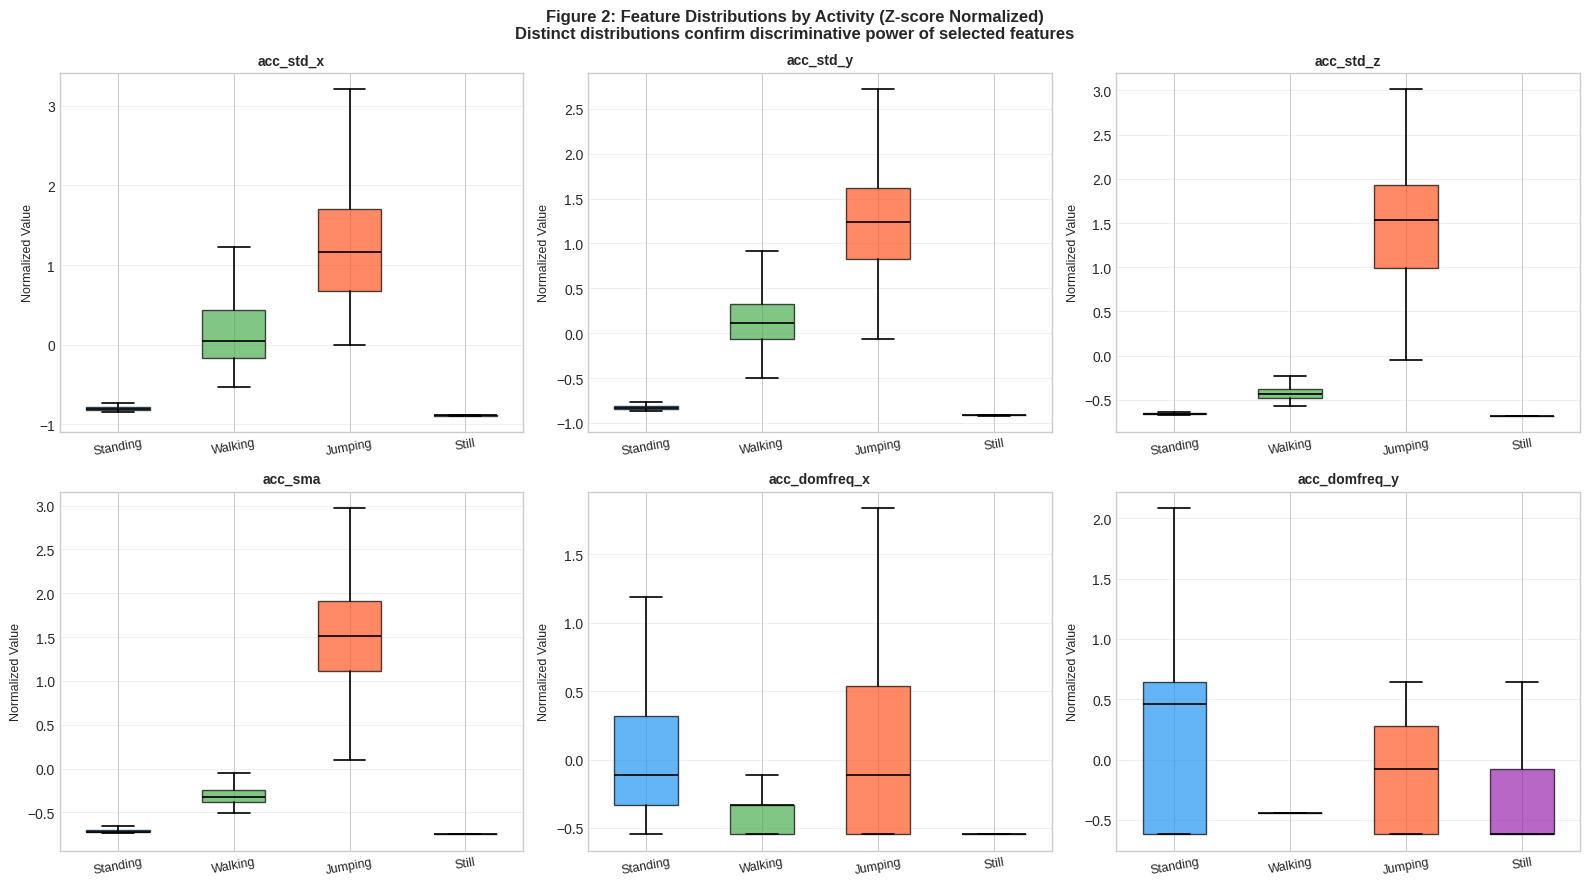

✅ Figure 2 saved → figures/fig2_feature_distributions.png


In [10]:
# Select the 6 most discriminative features for visualisation
key_feat_idx = [6, 7, 8, 18, 22, 24]   # acc_std xyz, acc_sma, domfreq x, domfreq y
key_labels   = [FEATURE_LABELS[i] for i in key_feat_idx]
colors_act   = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes      = axes.flatten()

for plot_idx, (fi, fname) in enumerate(zip(key_feat_idx, key_labels)):
    data_boxes = [X_train[y_train == ACTIVITY_MAP[a], fi] for a in ACTIVITIES]

    bp = axes[plot_idx].boxplot(data_boxes, patch_artist=True,
                                labels=[a.capitalize() for a in ACTIVITIES],
                                widths=0.55, showfliers=False)
    for patch, c in zip(bp['boxes'], colors_act):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    for element in ['whiskers','caps','medians']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)

    axes[plot_idx].set_title(fname, fontsize=10, fontweight='bold')
    axes[plot_idx].set_ylabel('Normalized Value', fontsize=9)
    axes[plot_idx].tick_params(axis='x', rotation=10, labelsize=9)
    axes[plot_idx].grid(True, alpha=0.3, axis='y')

fig.suptitle('Figure 2: Feature Distributions by Activity (Z-score Normalized)\n'
             'Distinct distributions confirm discriminative power of selected features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved → figures/fig2_feature_distributions.png")

In [11]:
def train_activity_hmm(sequences: list, activity_name: str) -> hmm.GaussianHMM:
    """
    Train a Gaussian HMM for one activity class using the Baum-Welch algorithm.
    Always uses N_COMPONENTS = 4 hidden states.
    """
    X_concat = np.vstack(sequences)
    lengths  = [len(s) for s in sequences]

    # Still activity needs special handling — very low variance data
    # causes standard initialization to collapse all states
    covar_type = 'full' if activity_name == 'still' else COVARIANCE_TYPE

    model = hmm.GaussianHMM(
        n_components    = N_COMPONENTS,
        covariance_type = covar_type,
        n_iter          = N_ITER,
        tol             = CONVERGENCE_TOL,
        random_state    = 42,
        verbose         = False,
        init_params     = 'smc',
        params          = 'stmc'
    )

    # Uniform transition matrix — all states equally reachable
    model.transmat_ = np.full(
        (N_COMPONENTS, N_COMPONENTS),
        1.0 / N_COMPONENTS
    )

    model.fit(X_concat, lengths)

    final_ll  = model.score(X_concat, lengths)
    converged = model.monitor_.converged
    n_iters   = len(model.monitor_.history)

    print(f"  {activity_name:<12} | "
          f"converged: {str(converged):<5} | "
          f"iterations: {n_iters:>3} | "
          f"log-likelihood: {final_ll:.2f}")
    return model


# ── Run training for all activities ───────────────────────────────────────────
print("🧠 Training HMMs using Baum-Welch algorithm...")
print("="*68)
print(f"  {'Activity':<12} | {'Converged':<12} | {'Iterations':>12} | Log-Likelihood")
print("-"*68)

models = {}
for activity in ACTIVITIES:
    seqs = sequences_scaled.get(activity, [])
    if not seqs:
        print(f"  ⚠ No sequences found for {activity} — check data directory")
        continue
    try:
        models[activity] = train_activity_hmm(seqs, activity)
    except Exception as e:
        print(f"  ❌ {activity} FAILED: {type(e).__name__}: {e}")

print("="*68)
print(f"\n✅ {len(models)}/4 HMMs trained")
print(f"   Convergence tolerance : {CONVERGENCE_TOL} (Δ log-likelihood)")
print(f"   Max iterations allowed: {N_ITER}")

🧠 Training HMMs using Baum-Welch algorithm...
  Activity     | Converged    |   Iterations | Log-Likelihood
--------------------------------------------------------------------
  standing     | converged: True  | iterations:  18 | log-likelihood: 15649.79


  walking      | converged: True  | iterations:  32 | log-likelihood: -767.69
  jumping      | converged: True  | iterations:  24 | log-likelihood: -7167.29


  still        | converged: True  | iterations:   5 | log-likelihood: 48497.23

✅ 4/4 HMMs trained
   Convergence tolerance : 0.0001 (Δ log-likelihood)
   Max iterations allowed: 200


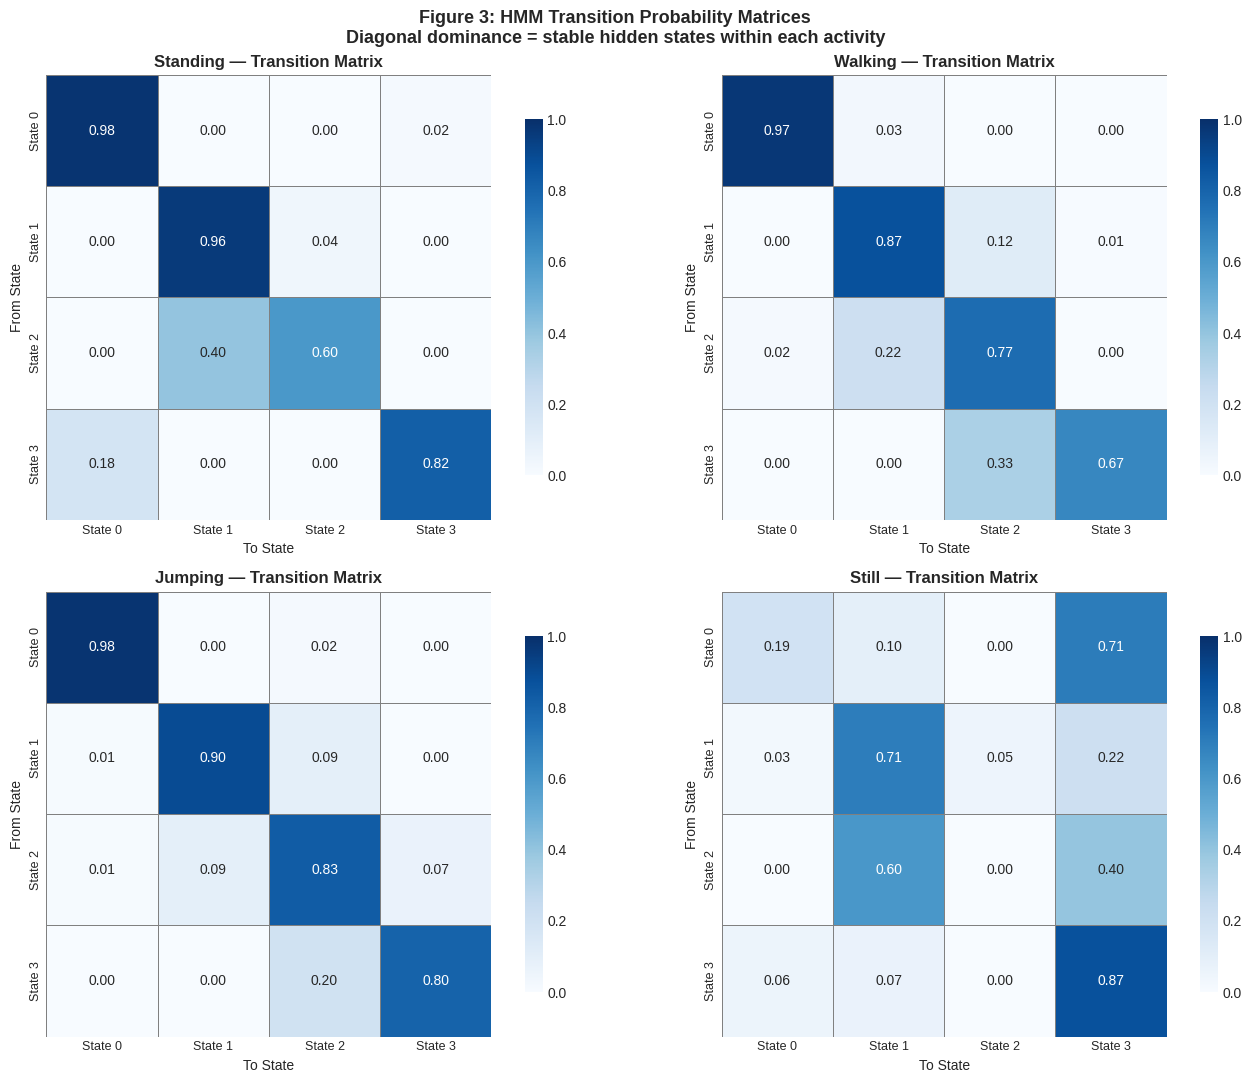

✅ Figure 3 saved


In [12]:
# ── Figure 3: Transition Probability Heatmaps ────────────────────────────────
plt.close('all')  # clear any lingering figure state

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, activity in enumerate(ACTIVITIES):
    ax = axes[idx]
    ax.clear()

    if activity not in models:
        ax.text(0.5, 0.5, f'No model for {activity}',
                ha='center', va='center', transform=ax.transAxes)
        continue

    # Convert to DataFrame — forces seaborn to treat labels as categorical
    trans = models[activity].transmat_
    labels = [f'State {i}' for i in range(N_COMPONENTS)]
    trans_df = pd.DataFrame(trans, index=labels, columns=labels)

    sns.heatmap(
        trans_df,                    # ✅ pass DataFrame not raw array
        annot=True,
        fmt='.2f',
        cmap='Blues',
        ax=ax,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='gray',
        square=True,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'{activity.capitalize()} — Transition Matrix',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('To State', fontsize=10)
    ax.set_ylabel('From State', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

fig.suptitle('Figure 3: HMM Transition Probability Matrices\n'
             'Diagonal dominance = stable hidden states within each activity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig3_transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")

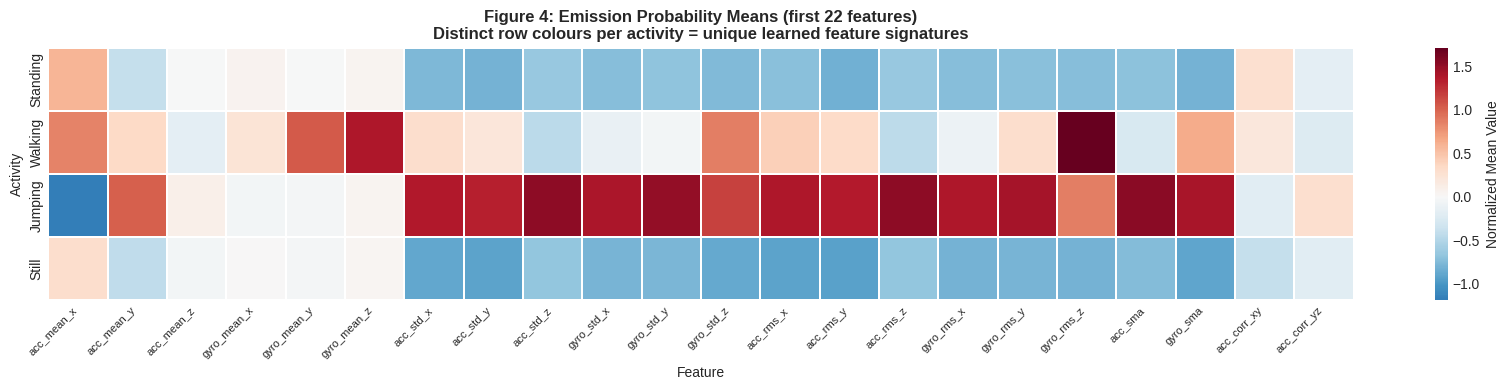

✅ Figure 4 saved → figures/fig4_emission_heatmap.png


In [13]:
# ── Figure 4: Emission Probability Means Heatmap ─────────────────────────────
emission_means = np.array([
    models[a].means_.mean(axis=0) for a in ACTIVITIES if a in models
])
act_labels_disp = [a.capitalize() for a in ACTIVITIES if a in models]
n_disp          = min(22, emission_means.shape[1])
feat_disp       = FEATURE_LABELS[:n_disp]

fig, ax = plt.subplots(figsize=(17, 4))
sns.heatmap(emission_means[:, :n_disp],
            xticklabels=feat_disp,
            yticklabels=act_labels_disp,
            cmap='RdBu_r', center=0,
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Normalized Mean Value'})
ax.set_title('Figure 4: Emission Probability Means (first 22 features)\n'
             'Distinct row colours per activity = unique learned feature signatures',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature', fontsize=10)
ax.set_ylabel('Activity', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('figures/fig4_emission_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved → figures/fig4_emission_heatmap.png")

In [14]:
def classify_window(feat_scaled: np.ndarray) -> tuple:
    """
    Classify one normalized feature vector against all activity HMMs.
    Uses Viterbi decoding (model.decode) for scoring.

    Returns
    -------
    best_activity : str   — predicted activity label
    best_score    : float — log-probability from winning HMM
    """
    x          = feat_scaled.reshape(1, -1)
    best_score = -np.inf
    best_act   = None

    for activity, model in models.items():
        try:
            log_prob, _ = model.decode(x, algorithm='viterbi')
            if log_prob > best_score:
                best_score = log_prob
                best_act   = activity
        except Exception:
            continue

    return best_act, best_score


def predict_recording(df: pd.DataFrame) -> list:
    """
    Predict activity label for every window in a recording.
    Returns a list of predicted activity strings.
    """
    cols  = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
    data  = df[cols].values.astype(np.float32)
    preds = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        feat    = extract_features(data[start : start + WINDOW_SIZE]).reshape(1, -1)
        feat_sc = scaler.transform(feat)
        pred, _ = classify_window(feat_sc)
        preds.append(pred)

    return preds


# ── Sanity check on 1 training file per activity ──────────────────────────────
print("🔍 Sanity check — predicting on 1 training file per activity:")
print("="*58)
for activity in ACTIVITIES:
    label  = ACTIVITY_MAP[activity]
    sample = next((df for df, lbl in train_data if lbl == label), None)
    if sample is not None:
        preds = predict_recording(sample)
        top   = Counter(preds).most_common(1)[0]
        pct   = top[1] / len(preds) * 100
        icon  = '✅' if top[0] == activity else '❌'
        print(f"  {icon} {activity:<12} → predicted '{top[0]:<12}' "
              f"({pct:.0f}% of {len(preds)} windows)")

🔍 Sanity check — predicting on 1 training file per activity:
  ✅ standing     → predicted 'standing    ' (100% of 20 windows)
  ✅ walking      → predicted 'walking     ' (100% of 20 windows)
  ✅ jumping      → predicted 'jumping     ' (100% of 21 windows)
  ✅ still        → predicted 'still       ' (100% of 19 windows)


In [15]:
print("📂 Loading unseen test data...")
print("="*50)
test_data, test_summary = load_dataset(TEST_DIR)

print(f"\n{'Activity':<12} {'Files':>6} {'Total Duration':>16}")
print("-"*36)
total_test = 0
for act, info in test_summary.items():
    print(f"{act:<12} {info['files']:>6}    {info['total_seconds']:>8.1f}s")
    total_test += info['files']
print("-"*36)
print(f"{'TOTAL':<12} {total_test:>6}")
print(f"\n✅ {len(test_data)} unseen test recordings loaded")

📂 Loading unseen test data...

Activity      Files   Total Duration
------------------------------------
standing          3        31.2s
walking           3        33.1s
jumping           4        45.8s
still             3        31.1s
------------------------------------
TOTAL            13

✅ 13 unseen test recordings loaded


🔮 Running Viterbi decoding on unseen test data...
✅ 265 windows evaluated on test data


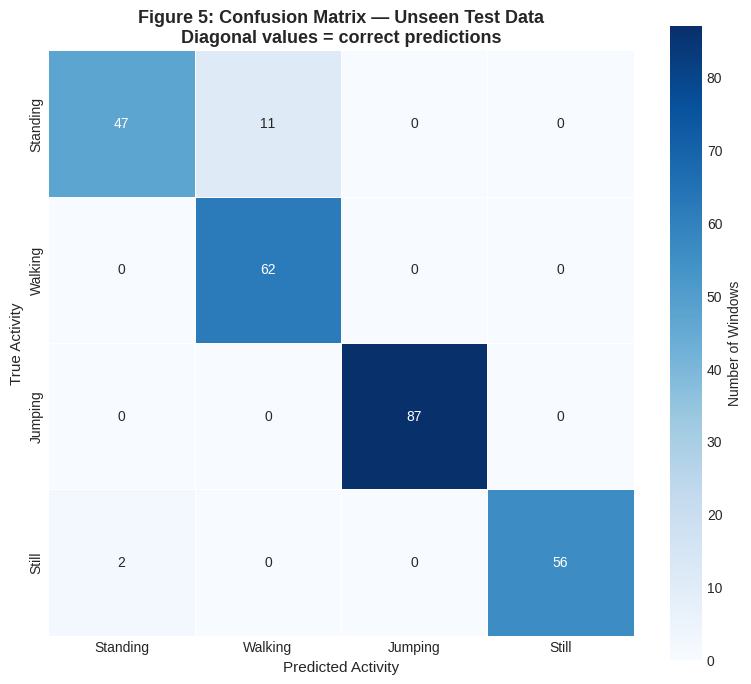

✅ Figure 5 saved → figures/fig5_confusion_matrix.png


In [16]:
# ── Run Viterbi predictions on all test recordings ────────────────────────────
print("🔮 Running Viterbi decoding on unseen test data...")
y_true_all, y_pred_all = [], []

for df, true_label in test_data:
    preds = predict_recording(df)
    y_pred_all.extend([ACTIVITY_MAP.get(p, -1) for p in preds])
    y_true_all.extend([true_label] * len(preds))

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
print(f"✅ {len(y_true)} windows evaluated on test data")

# ── Figure 5: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[a.capitalize() for a in ACTIVITIES],
            yticklabels=[a.capitalize() for a in ACTIVITIES],
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'label': 'Number of Windows'})
ax.set_title('Figure 5: Confusion Matrix — Unseen Test Data\n'
             'Diagonal values = correct predictions',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Activity', fontsize=11)
ax.set_ylabel('True Activity', fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved → figures/fig5_confusion_matrix.png")

In [17]:
# ── Per-class Metrics Table ───────────────────────────────────────────────────
print("\n" + "="*68)
print(f"  {'Activity':<12} {'Samples':>8} {'Sensitivity':>13} "
      f"{'Specificity':>13} {'Accuracy':>10}")
print("="*68)

correct = 0
rows    = []
for i, activity in enumerate(ACTIVITIES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sens = TP / (TP + FN + 1e-9)
    spec = TN / (TN + FP + 1e-9)
    acc  = (TP + TN) / cm.sum()
    n    = int(cm[i, :].sum())
    correct += TP

    rows.append({'Activity': activity.capitalize(), 'Samples': n,
                 'Sensitivity': round(sens, 3), 'Specificity': round(spec, 3),
                 'Accuracy': round(acc, 3)})
    print(f"  {activity.capitalize():<12} {n:>8} {sens:>13.3f} "
          f"{spec:>13.3f} {acc:>10.3f}")

overall_acc = correct / len(y_true)
print("="*68)
print(f"  {'OVERALL ACCURACY':<36} {overall_acc:>10.3f}")

print("\n📋 Full Classification Report:")
print(classification_report(y_true, y_pred,
      target_names=[a.capitalize() for a in ACTIVITIES]))

print("\n📋 Results Table (copy into report):")
print(pd.DataFrame(rows).to_string(index=False))


  Activity      Samples   Sensitivity   Specificity   Accuracy
  Standing           58         0.810         0.990      0.951
  Walking            62         1.000         0.946      0.958
  Jumping            87         1.000         1.000      1.000
  Still              58         0.966         1.000      0.992
  OVERALL ACCURACY                          0.951

📋 Full Classification Report:
              precision    recall  f1-score   support

    Standing       0.96      0.81      0.88        58
     Walking       0.85      1.00      0.92        62
     Jumping       1.00      1.00      1.00        87
       Still       1.00      0.97      0.98        58

    accuracy                           0.95       265
   macro avg       0.95      0.94      0.94       265
weighted avg       0.96      0.95      0.95       265


📋 Results Table (copy into report):
Activity  Samples  Sensitivity  Specificity  Accuracy
Standing       58        0.810        0.990     0.951
 Walking       62      

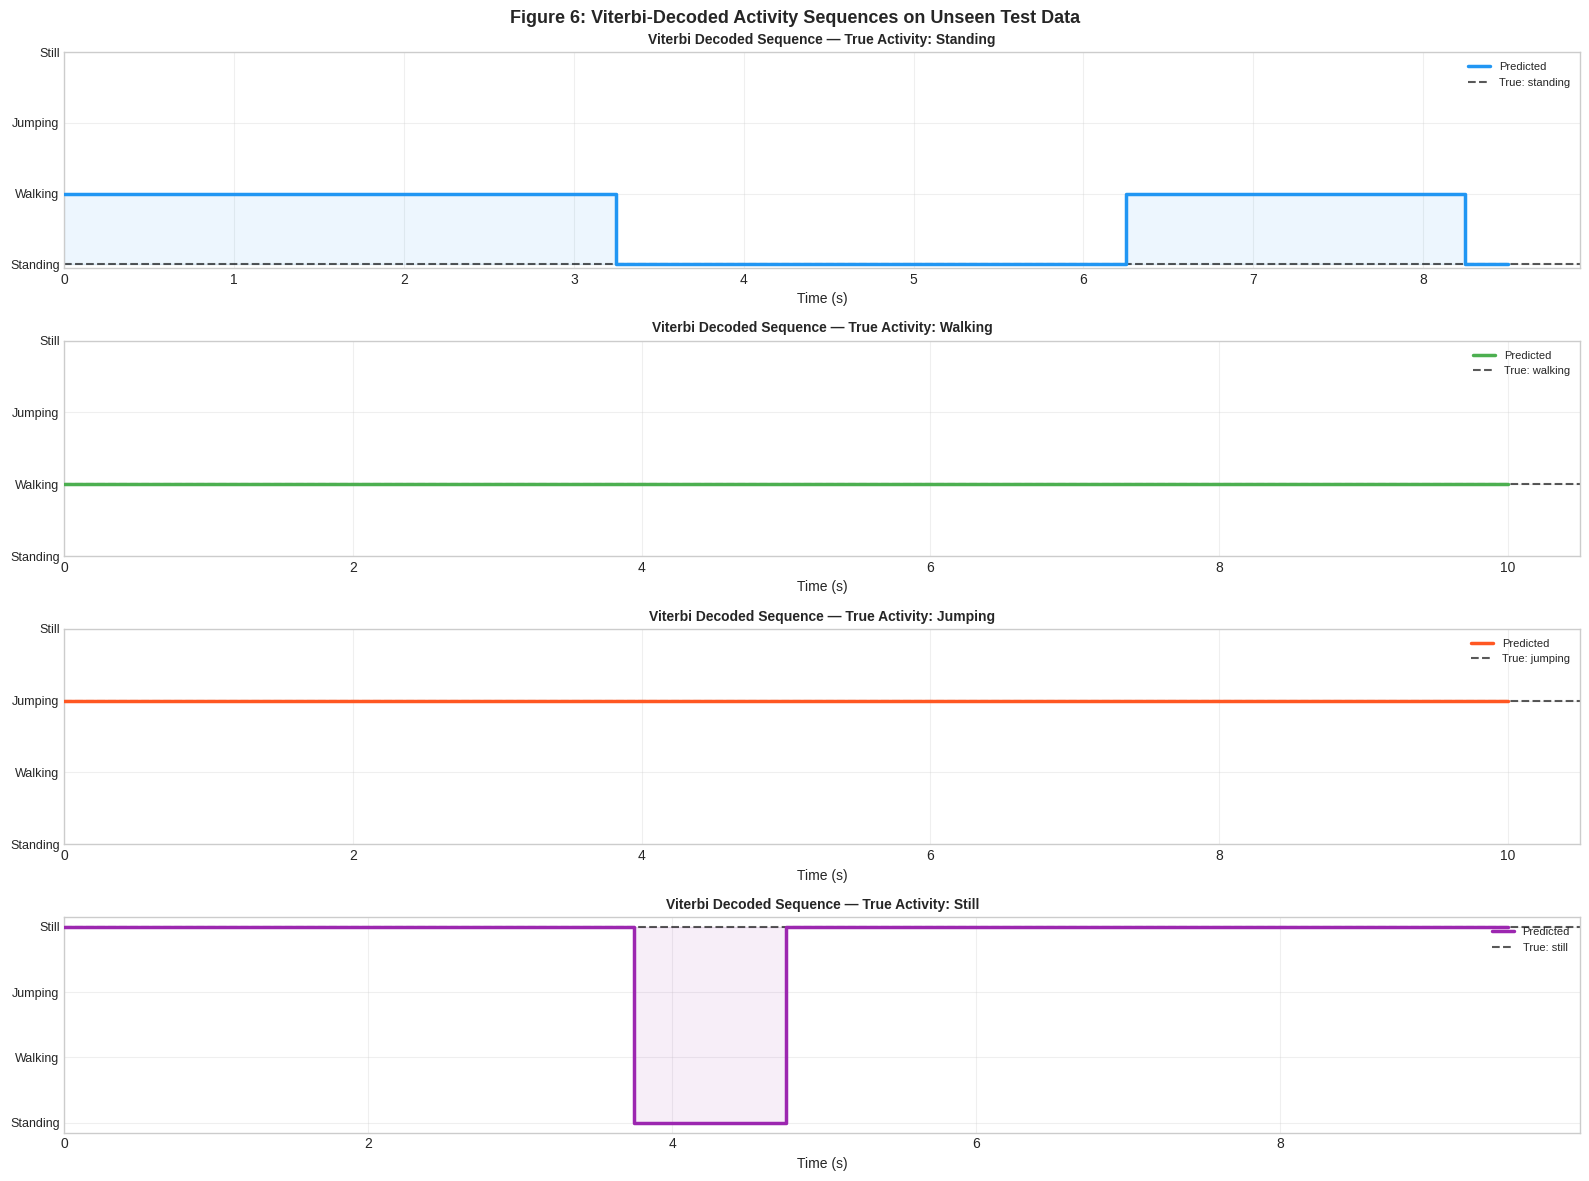

✅ Figure 6 saved → figures/fig6_decoded_sequences.png


In [18]:
colors_act = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
fig, axes  = plt.subplots(len(ACTIVITIES), 1, figsize=(16, 12))

for idx, activity in enumerate(ACTIVITIES):
    label  = ACTIVITY_MAP[activity]
    sample = next((df for df, lbl in test_data if lbl == label), None)

    if sample is None:
        axes[idx].text(0.5, 0.5, f'No test file for {activity}',
                       ha='center', va='center', transform=axes[idx].transAxes)
        continue

    preds     = predict_recording(sample)
    pred_nums = [ACTIVITY_MAP.get(p, -1) for p in preds]
    t_axis    = np.arange(len(pred_nums)) * STEP_SIZE / SAMPLING_RATE

    axes[idx].step(t_axis, pred_nums, where='mid',
                   color=colors_act[idx], linewidth=2.5, label='Predicted', zorder=3)
    axes[idx].axhline(label, color='black', linestyle='--',
                      alpha=0.65, linewidth=1.5, label=f'True: {activity}')
    axes[idx].fill_between(t_axis, pred_nums, label, alpha=0.08,
                           color=colors_act[idx], step='mid')
    axes[idx].set_yticks(list(ACTIVITY_MAP.values()))
    axes[idx].set_yticklabels([a.capitalize() for a in ACTIVITIES], fontsize=9)
    axes[idx].set_title(f'Viterbi Decoded Sequence — True Activity: {activity.capitalize()}',
                        fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Time (s)')
    axes[idx].legend(loc='upper right', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(left=0)

fig.suptitle('Figure 6: Viterbi-Decoded Activity Sequences on Unseen Test Data',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig6_decoded_sequences.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved → figures/fig6_decoded_sequences.png")

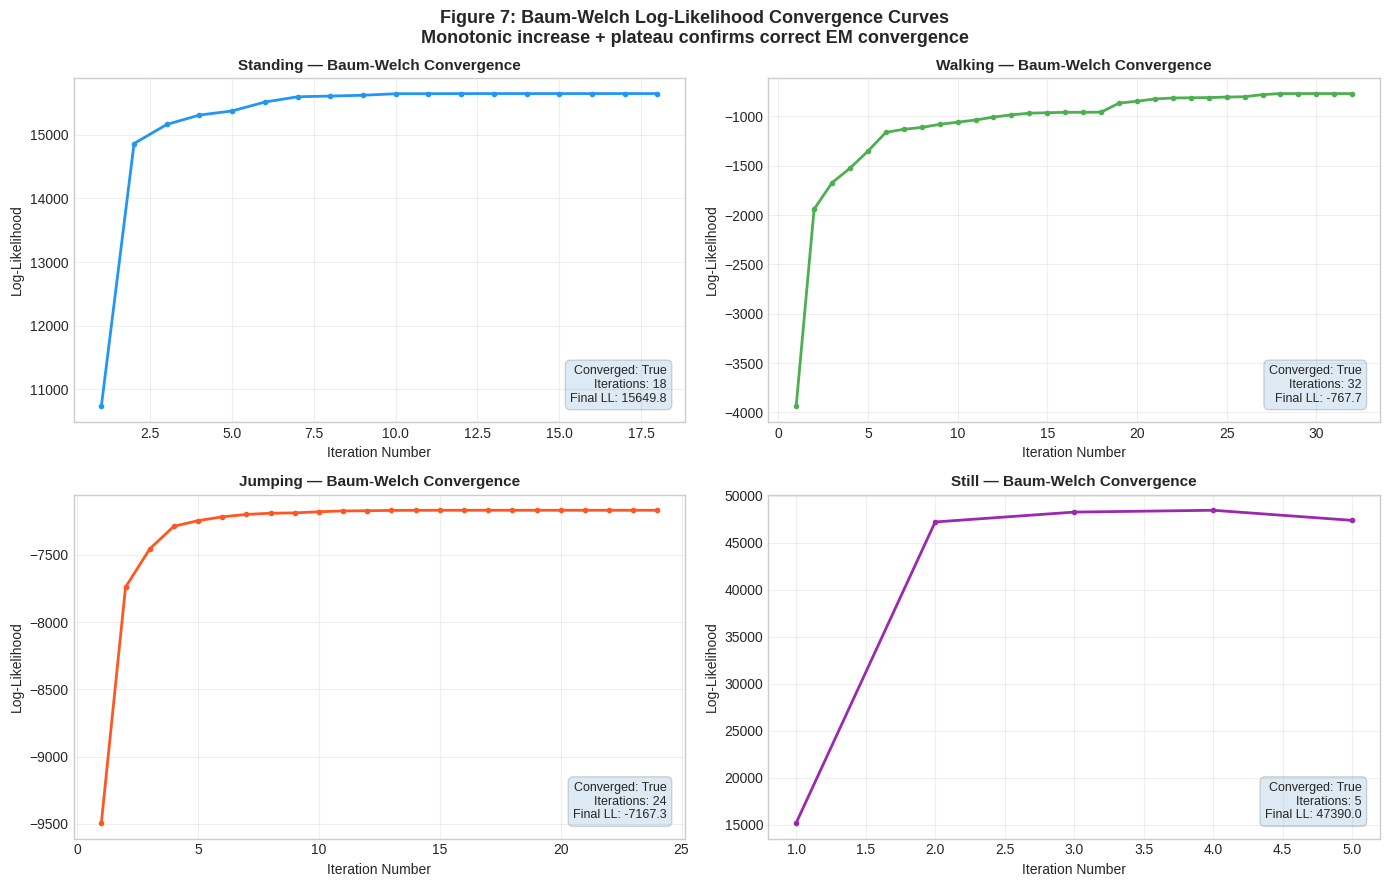

✅ Figure 7 saved → figures/fig7_convergence.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, activity in enumerate(ACTIVITIES):
    if activity not in models:
        continue
    model   = models[activity]
    history = model.monitor_.history

    axes[idx].plot(range(1, len(history) + 1), history,
                   color=colors_act[idx], linewidth=2,
                   marker='o', markersize=3, markevery=max(1, len(history)//20))
    axes[idx].set_title(f'{activity.capitalize()} — Baum-Welch Convergence',
                        fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Iteration Number', fontsize=10)
    axes[idx].set_ylabel('Log-Likelihood', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

    info_text = (f"Converged: {model.monitor_.converged}\n"
                 f"Iterations: {len(history)}\n"
                 f"Final LL: {history[-1]:.1f}")
    axes[idx].text(0.97, 0.05, info_text, transform=axes[idx].transAxes,
                   ha='right', va='bottom', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.4', alpha=0.15))

fig.suptitle('Figure 7: Baum-Welch Log-Likelihood Convergence Curves\n'
             'Monotonic increase + plateau confirms correct EM convergence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved → figures/fig7_convergence.png")

In [20]:
print("=" * 65)
print("             FINAL MODEL SUMMARY")
print("=" * 65)
print(f"  Sampling Rate       : {SAMPLING_RATE} Hz (harmonized from 99.4 Hz)")
print(f"  Window Size         : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f}s")
print(f"  Step Size           : {STEP_SIZE} samples (50% overlap)")
print(f"  Feature Dimensions  : {X_train.shape[1]}")
print(f"  Training Windows    : {X_train.shape[0]}")
print(f"  Test Windows        : {len(y_true)}")
print(f"  HMM States / Model  : {N_COMPONENTS}")
print(f"  Covariance Type     : {COVARIANCE_TYPE}")
print(f"  Convergence Tol     : {CONVERGENCE_TOL}")
print()
print("  Baum-Welch Convergence:")
for act in ACTIVITIES:
    if act in models:
        m      = models[act]
        status = '✅ Converged' if m.monitor_.converged else '⚠  Not converged'
        print(f"    {act.capitalize():<12}: {status} ({len(m.monitor_.history)} iterations)")
print()
print(f"  Overall Test Accuracy : {overall_acc:.1%}")
print("=" * 65)
print()
print("  📁 Figures saved to figures/:")
fnames = ['raw_signals','feature_distributions','transition_matrices',
          'emission_heatmap','confusion_matrix','decoded_sequences','convergence']
for i, name in enumerate(fnames, 1):
    print(f"     fig{i}_{name}.png")

             FINAL MODEL SUMMARY
  Sampling Rate       : 100 Hz (harmonized from 99.4 Hz)
  Window Size         : 100 samples = 1.0s
  Step Size           : 50 samples (50% overlap)
  Feature Dimensions  : 30
  Training Windows    : 1127
  Test Windows        : 265
  HMM States / Model  : 4
  Covariance Type     : diag
  Convergence Tol     : 0.0001

  Baum-Welch Convergence:
    Standing    : ✅ Converged (18 iterations)
    Walking     : ✅ Converged (32 iterations)
    Jumping     : ✅ Converged (24 iterations)
    Still       : ✅ Converged (5 iterations)

  Overall Test Accuracy : 95.1%

  📁 Figures saved to figures/:
     fig1_raw_signals.png
     fig2_feature_distributions.png
     fig3_transition_matrices.png
     fig4_emission_heatmap.png
     fig5_confusion_matrix.png
     fig6_decoded_sequences.png
     fig7_convergence.png
